In [ ]:
# Scenario-Based Question
# A university wants to build a predictive model to estimate
#  student grades based on four factors:
# - Study hours per week
# - Attendance percentage
# - Previous exam score
# - Average sleep hours
# They collect data from 200 students and decide to use Ridge
#  Regression for prediction. To evaluate the model, they apply different cross-validation strategies:
# - Basic K-Fold CV (5 folds, shuffled) to check the stability of the model’s R² scores.
# - Multi-metric evaluation using both R² and Mean Squared Error (MSE), comparing training and validation
# scores.
# - Stratified K-Fold CV (for a separate classification task predicting pass/fail using Logistic
#                         Regression).

In [1]:
from sklearn.model_selection import KFold, cross_val_score 
from sklearn.linear_model import LinearRegression 
from sklearn.datasets import make_regression 
import numpy as np

In [2]:
# create synthetic dataset
# 1000 samples, 5 features (size, bedrooms, age, distance, school rating)
X,y = make_regression(n_samples=1000, 
                      n_features=5,
                      noise=15, # we have put some random variation to data so that data should not look perfect
                      random_state=42)

In [3]:
model = LinearRegression()

In [4]:
# Define 5-fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [5]:
scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

In [7]:
print("R^2 scores for each fold:", scores.round(3))
print("Mean R^2:", scores.mean().round(3))
print("Std Dev:", scores.std().round(3))

R^2 scores for each fold: [0.937 0.945 0.945 0.947 0.947]
Mean R^2: 0.944
Std Dev: 0.004


In [8]:
if scores.std() < 0.05:
    print("Model is stable across folds.")
else:
    print("Model performance varies across folds, investigate further.")
    

Model is stable across folds.


In [ ]:
# Scenario: Predicting Patient Recovery Time
# A hospital research team wants to build a model to predict patient recovery time (in days) after
#  surgery based on several factors such as:
# - Age of the patient
# - Number of hours of post-surgery physiotherapy per week
# - Pre-existing health conditions (numeric severity score)
# - Length of hospital stay (days)
# - Average sleep hours during recovery
# They collect data from 1,000 patients and decide to use Linear Regression.
# To evaluate the model, they apply 5-Fold Cross-Validation with R² as the performance metric.

In [9]:
from sklearn.model_selection import KFold, cross_val_score 
from sklearn.linear_model import LinearRegression 
from sklearn.datasets import make_regression 
import numpy as np

In [10]:
X, y = make_regression(n_samples=1000, 
                       n_features=5, 
                       noise=10, 
                       random_state=42)

In [11]:
model = LinearRegression()

In [12]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [13]:
scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

In [16]:
print("R² score for each fold:", scores)
print("Average R² score:", scores.mean())
print("Std Dev:", scores.std().round(3))

R² score for each fold: [0.97105479 0.9746551  0.97511554 0.97585063 0.97595096]
Average R² score: 0.9745254033330852
Std Dev: 0.002


In [15]:
if scores.std() < 0.05:
    print("Model is stable across folds.")
else:
    print("Model performance varies across folds, investigate further.")

Model is stable across folds.


In [ ]:
# Scenario: Predicting Student Exam Performance
# A university research team wants to build a model to predict student exam scores (out of 100) based on several factors such as:
# - Number of study hours per week
# - Attendance percentage in lectures
# - Prior GPA (Grade Point Average)
# - Participation in group projects (numeric engagement score)
# - Average sleep hours during exam preparation
# They collect data from 800 students across different departments and decide to use Linear Regression.
# To evaluate the model, they apply 5-Fold Cross-Validation with R² as the performance metric.

In [17]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=800, 
                       n_features=5, 
                       noise=10, 
                       random_state=42)

model = LinearRegression()

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

print("R² score for each fold:", scores)
print("Average R² score:", scores.mean())
print("Std Dev:", scores.std().round(3))
if scores.std() < 0.05:
    print("Model is stable across folds.")
else:
    print("Model performance varies across folds, investigate further.")

R² score for each fold: [0.99410469 0.99441737 0.99515087 0.99469966 0.99457228]
Average R² score: 0.9945889761098206
Std Dev: 0.0
Model is stable across folds.


In [ ]:
# High bias in Machine Learning means your model is too simple to capture the real pattern in the data.

In [ ]:
# Scenario: Predicting Student Exam Scores
# A school wants to build a model to predict student exam scores based on study hours. They collect data
# from 30 students, but the scores are noisy because of other factors (like sleep, stress, or health).
# They try two different models:
# - Linear Model (straight line) → very simple, assumes scores increase perfectly with study hours.
# - Polynomial Model (degree 10 curve) → very complex, tries to follow every bump in the data.

# Questions
# - Part A: If the linear model consistently predicts too low or too high compared to actual scores,
# what does this show about bias?
# - Part B: If the polynomial model fits the training data almost perfectly but gives very different predictions when tested on new students, what does this show about variance?
# - Part C: Which model is likely to generalize better to new students, and why?
# - Part D (Applied): How would you explain the difference between “high bias” and “high variance” to
#  a teacher who doesn’t know machine learning?

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

In [19]:
# simulate dataset
np.random.seed(0)
X = np.linspace(0,6,30).reshape(-1,1) #study hours
y = (10* np.sin(X)).ravel() + np.random.normal(scale=3, size=30) #exam score with noise

In [22]:
# define models
linear_model = make_pipeline(PolynomialFeatures(1), LinearRegression()) #simple line
poly_model = make_pipeline(PolynomialFeatures(10), LinearRegression()) #complex curve
balanced_model = make_pipeline(PolynomialFeatures(3), LinearRegression()) #just right

In [23]:
linear_model.fit(X,y)
poly_model.fit(X,y)
balanced_model.fit(X,y)

,steps,"[('polynomialfeatures', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,3
,interaction_only,False
,include_bias,True
,order,'C'
,fit_intercept,True
,copy_X,True
,tol,1e-06


In [24]:
# Prediction
X_test = np.linspace(0,6,100).reshape(-1,1)
y_linear = linear_model.predict(X_test)
y_poly = poly_model.predict(X_test)
y_balanced = balanced_model.predict(X_test)

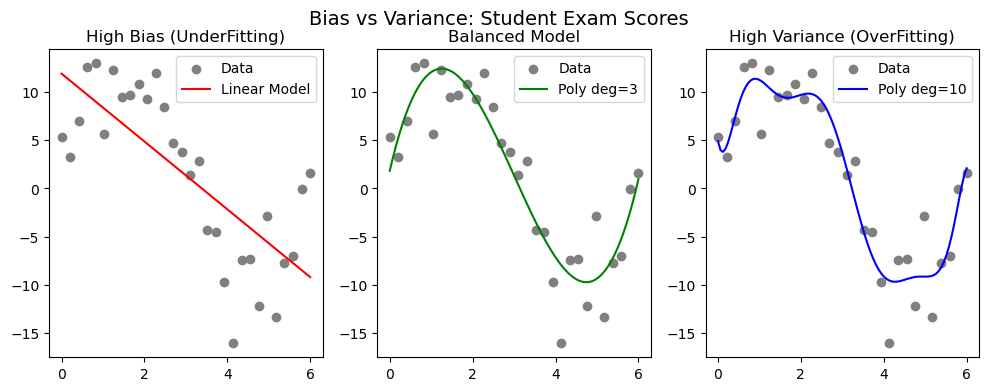

In [26]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.scatter(X,y,color="gray", label="Data")
plt.plot(X_test, y_linear, color="red", label="Linear Model")
plt.title("High Bias (UnderFitting)")
plt.legend()

plt.subplot(1,3,2)
plt.scatter(X,y,color="gray", label="Data")
plt.plot(X_test, y_balanced, color="green", label="Poly deg=3")
plt.title("Balanced Model")
plt.legend()

plt.subplot(1,3,3)
plt.scatter(X,y,color="gray", label="Data")
plt.plot(X_test, y_poly, color="blue", label="Poly deg=10")
plt.title("High Variance (OverFitting)")
plt.legend()

plt.suptitle("Bias vs Variance: Student Exam Scores", fontsize=14)
plt.show()

In [ ]:
# Scenario: Predicting Athlete Performance
# A sports academy wants to build a model to predict athlete sprint times (in seconds) based on training
#  hours. They collect data from 30 athletes, but the sprint times are noisy because of other factors (like diet, fatigue, or weather).
# They try two different models:
# - Linear Model (straight line) → very simple, assumes sprint times improve perfectly with more
#  training hours.
# - Polynomial Model (degree 10 curve) → very complex, tries to follow every bump in the data.

# Questions
# - Part A: If the linear model consistently predicts sprint times that are too fast or too slow compared
#  to actual results, what does this show about bias?
# - Part B: If the polynomial model fits the training data almost perfectly but gives very different
# predictions when tested on new athletes, what does this show about variance?
# - Part C: Which model is likely to generalize better to new athletes, and why?
# - Part D (Applied): How would you explain the difference between “high bias” and “high variance”
#  to a coach who doesn’t know machine learning?

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

In [28]:
np.random.seed(0)

X = np.linspace(0, 6, 30).reshape(-1, 1)
y = (10 * np.sin(X)).ravel() + np.random.normal(scale=3, size=30)

In [29]:
linear_model = make_pipeline(PolynomialFeatures(1), LinearRegression())   
balanced_model = make_pipeline(PolynomialFeatures(3), LinearRegression())  
poly_model = make_pipeline(PolynomialFeatures(10), LinearRegression()) 

In [30]:
linear_model.fit(X, y)
balanced_model.fit(X, y)
poly_model.fit(X, y)

,steps,"[('polynomialfeatures', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,10
,interaction_only,False
,include_bias,True
,order,'C'
,fit_intercept,True
,copy_X,True
,tol,1e-06


In [31]:
X_test = np.linspace(0, 6, 100).reshape(-1, 1)

y_linear = linear_model.predict(X_test)
y_balanced = balanced_model.predict(X_test)
y_poly = poly_model.predict(X_test)

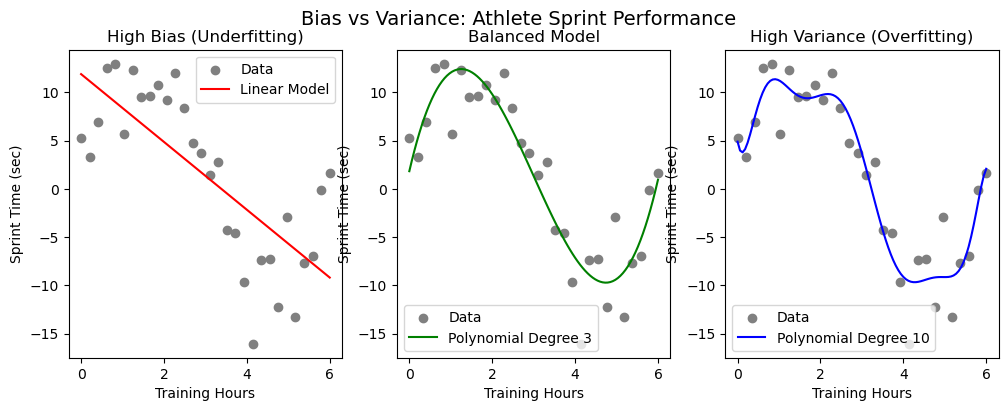

In [32]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_linear, color="red", label="Linear Model")
plt.title("High Bias (Underfitting)")
plt.xlabel("Training Hours")
plt.ylabel("Sprint Time (sec)")
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_balanced, color="green", label="Polynomial Degree 3")
plt.title("Balanced Model")
plt.xlabel("Training Hours")
plt.ylabel("Sprint Time (sec)")
plt.legend()

# High Variance (Overfitting)
plt.subplot(1, 3, 3)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_poly, color="blue", label="Polynomial Degree 10")
plt.title("High Variance (Overfitting)")
plt.xlabel("Training Hours")
plt.ylabel("Sprint Time (sec)")
plt.legend()

plt.suptitle("Bias vs Variance: Athlete Sprint Performance", fontsize=14)
plt.show()

In [ ]:
# Bias (Underfitting)
# Bias = wrong assumptions in the model
# Model is too simple
# Cannot capture the real pattern
# Performs poorly on both training and test data

# Variance (Overfitting)
# Variance = model reacts too much to small changes in data
# Model is too complex
# Learns noise instead of pattern
# Performs well on training data but poorly on new data

In [ ]:
# Label Encoding in ML# Scenario: Package Delivery System
# A logistics company wants to build a machine learning model to optimize package delivery.
# They collect data about each package, including:
# - Size: Small, Medium, Large
# - Priority: Low, Medium, High
# Since machine learning models work with numbers (not text labels), the company decides to use Label
#  Encoding to convert these categories into numeric values.
# They apply Scikit-learn’s LabelEncoder to both features:
# - Size → converted into numeric codes (e.g., Small = 2, Medium = 1, Large = 0)
# - Priority → converted into numeric codes (e.g., Low = 1, Medium = 2, High = 0)
# They also check the mapping and decode the numbers back to the original labels to ensure correctness.

# Questions for Learners
# Part A: Why does the company need to convert categorical values like Small, Medium, Large into numbers 
# before training a model?
# Part B: If the encoded values are 0, 1, 2, does the order (e.g., Large = 0, Medium = 1, Small = 2) 
# matter for all models? Why or why not?
# Part C: How can the company decode the numeric values back into the original labels after prediction?
# Part D (Applied): Suppose the company adds a new category “Extra Large.” How would LabelEncoder handle 
# this, and what challenge might arise if the model was already trained?

In [36]:
# import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

In [37]:
data = pd.DataFrame({
    'Size': ['Small', 'Medium', 'Large', 'Medium', 'Small'],
    'Priority': ['Low', 'High', 'Medium', 'Low', 'High']
})

In [40]:
le_size = LabelEncoder()
data['Size_Encoded'] = le_size.fit_transform(data['Size'])
le_priority = LabelEncoder()
data['Priority_Encoded'] = le_priority.fit_transform(data['Priority'])

In [41]:
print("Size mapping:", dict(zip(le_size.classes_, le_size.transform(le_size.classes_))))
print("Priority mapping:", dict(zip(le_priority.classes_, le_priority.transform(le_priority.classes_))))


Size mapping: {'Large': np.int64(0), 'Medium': np.int64(1), 'Small': np.int64(2)}
Priority mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


In [42]:
decoded_size = le_size.inverse_transform([0, 1, 2])
print("Decoded Size:", decoded_size)

Decoded Size: ['Large' 'Medium' 'Small']


In [43]:
print("\nEncoded DataFrame:")
print(data)


Encoded DataFrame:
     Size Priority  Size_Encoded  Priority_Encoded
0   Small      Low             2                 1
1  Medium     High             1                 0
2   Large   Medium             0                 2
3  Medium      Low             1                 1
4   Small     High             2                 0


In [ ]:
# Scenario: Restaurant Ordering System
# A restaurant wants to build a machine learning model to predict order preparation time.
# They collect data about each order, including:
# - Meal Type: Breakfast, Lunch, Dinner
# - Spice Level: Mild, Medium, Hot
# Since models can’t directly work with text labels, the restaurant uses Label Encoding to 
# convert these categories into numbers.

In [45]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

In [46]:
data = pd.DataFrame({
    "Meal_Type": ["Breakfast", "Lunch", "Dinner", "Lunch", "Breakfast"],
    "Spice_Level": ["Mild", "Hot", "Medium", "Hot", "Mild"]
})

In [47]:
le_meal = LabelEncoder()
le_spice = LabelEncoder()

In [48]:
data["Meal_Type_Encoded"] = le_meal.fit_transform(data["Meal_Type"])
data["Spice_Level_Encoded"] = le_spice.fit_transform(data["Spice_Level"])

print(data)

   Meal_Type Spice_Level  Meal_Type_Encoded  Spice_Level_Encoded
0  Breakfast        Mild                  0                    2
1      Lunch         Hot                  2                    0
2     Dinner      Medium                  1                    1
3      Lunch         Hot                  2                    0
4  Breakfast        Mild                  0                    2


In [ ]:
# Scenario: Employee Training & Satisfaction Survey
# A company conducts a survey to understand how employee education level and job satisfaction affect performance.
# They collect data such as:
# - Education: High School, Bachelor, Master, PhD
# - Satisfaction: Poor, Average, Good, Excellent
# Since these categories have a natural order (e.g., PhD is higher than Bachelor, Excellent is better
#  than Good), the company decides to use Ordinal Encoding to convert them into numbers that respect 
#  this ranking.
# They define custom ordering:
# - Education → High School (0), Bachelor (1), Master (2), PhD (3)
# - Satisfaction → Poor (0), Average (1), Good (2), Excellent (3)
# They also compare this with a manual dictionary mapping to ensure consistency.

# Questions for Learners
# Part A: Why is it important to use Ordinal Encoding instead of simple Label Encoding for ordered 
# categories like education level?
# Part B: If the company encoded “PhD = 0” and “High School = 3,” what problem might arise in 
# interpreting the model?
# Part C: How does Ordinal Encoding differ from One-Hot Encoding in representing categorical data?
# Part D (Applied): Suppose the company adds a new satisfaction level “Outstanding.” How should they 
# update their encoding scheme to keep the order meaningful?

In [51]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder 

In [52]:
data = pd.DataFrame({
    'Education': ['Bachelor', 'PhD', 'Master', 'High School'],
    'Satisfaction': ['Good', 'Excellent', 'Poor', 'Average']
})

In [53]:
education_order = [['High School', 'Bachelor', 'Master', 'PhD']]
satisfaction_order = [['Poor', 'Average', 'Good', 'Excellent']]

In [55]:
edu_encoder = OrdinalEncoder(categories=education_order)
data['Education_Encoded'] = edu_encoder.fit_transform(data[['Education']])
sat_encoder = OrdinalEncoder(categories=satisfaction_order)
data['Satisfaction_Encoded'] = sat_encoder.fit_transform(data[['Satisfaction']])

In [56]:
education_map = {
    'High School':0, 'Bachelor':1,
    'Master':2, 'PhD':3
}
satisfaction_map = {
    'Poor':0, 'Average':1,
    'Good':2, 'Excellent':3
}
data['Education_Manual'] = data['Education'].map(education_map)
data['Satisfaction_Manual'] = data['Satisfaction'].map(satisfaction_map)

In [63]:
print(data)

  Disease_Severity Recovery_Satisfaction  Severity_Encoded  \
0             Mild                  Good               0.0   
1           Severe                  Poor               2.0   
2         Moderate               Average               1.0   
3         Critical             Excellent               3.0   
4             Mild                  Good               0.0   

   Satisfaction_Encoded  Severity_Manual  Satisfaction_Manual  
0                   2.0                0                    2  
1                   0.0                2                    0  
2                   1.0                1                    1  
3                   3.0                3                    3  
4                   2.0                0                    2  


In [ ]:
# Scenario: Patient Health Monitoring
# A hospital wants to analyze patient records to understand how disease severity and recovery 
# satisfaction affect treatment outcomes.
# They collect data such as:
# - Disease Severity: Mild, Moderate, Severe, Critical
# - Recovery Satisfaction: Poor, Average, Good, Excellent
# Since these categories have a natural order (e.g., Critical is worse than Mild, Excellent is 
# better than Poor), the hospital uses Ordinal Encoding to convert them into numbers that respect this
#  ranking.
# They define custom ordering:
# - Disease Severity → Mild (0), Moderate (1), Severe (2), Critical (3)
# - Recovery Satisfaction → Poor (0), Average (1), Good (2), Excellent (3)
# They also compare this with a manual dictionary mapping to ensure consistency.

In [57]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

In [58]:
data = pd.DataFrame({
    'Disease_Severity': ['Mild', 'Severe', 'Moderate', 'Critical', 'Mild'],
    'Recovery_Satisfaction': ['Good', 'Poor', 'Average', 'Excellent', 'Good']
})

In [59]:
severity_order = [['Mild', 'Moderate', 'Severe', 'Critical']]
satisfaction_order = [['Poor', 'Average', 'Good', 'Excellent']]

In [60]:
encoder = OrdinalEncoder(categories=severity_order + satisfaction_order)
data[['Severity_Encoded', 'Satisfaction_Encoded']] = encoder.fit_transform(
    data[['Disease_Severity', 'Recovery_Satisfaction']]
)

In [61]:
print("\nAfter Ordinal Encoding (sklearn):")
print(data)


After Ordinal Encoding (sklearn):
  Disease_Severity Recovery_Satisfaction  Severity_Encoded  \
0             Mild                  Good               0.0   
1           Severe                  Poor               2.0   
2         Moderate               Average               1.0   
3         Critical             Excellent               3.0   
4             Mild                  Good               0.0   

   Satisfaction_Encoded  
0                   2.0  
1                   0.0  
2                   1.0  
3                   3.0  
4                   2.0  


In [62]:
severity_map = {'Mild': 0, 'Moderate': 1, 'Severe': 2, 'Critical': 3}
satisfaction_map = {'Poor': 0, 'Average': 1, 'Good': 2, 'Excellent': 3}

data['Severity_Manual'] = data['Disease_Severity'].map(severity_map)
data['Satisfaction_Manual'] = data['Recovery_Satisfaction'].map(satisfaction_map)

print("\nAfter Manual Dictionary Encoding:")
print(data)


After Manual Dictionary Encoding:
  Disease_Severity Recovery_Satisfaction  Severity_Encoded  \
0             Mild                  Good               0.0   
1           Severe                  Poor               2.0   
2         Moderate               Average               1.0   
3         Critical             Excellent               3.0   
4             Mild                  Good               0.0   

   Satisfaction_Encoded  Severity_Manual  Satisfaction_Manual  
0                   2.0                0                    2  
1                   0.0                2                    0  
2                   1.0                1                    1  
3                   3.0                3                    3  
4                   2.0                0                    2  


In [ ]:
# Scenario: Online Food Delivery App
# An online food delivery company wants to build a machine learning model to predict delivery time based
#  on the type of cuisine ordered.
# They collect data such as:
# - Cuisine Type: Italian, Chinese, Indian, Mexican
# Since machine learning models can’t directly work with text labels, the company decides to use One-Hot
#  Encoding.
# This method creates a new column for each cuisine type:
# - Italian → [1, 0, 0, 0]
# - Chinese → [0, 1, 0, 0]
# - Indian → [0, 0, 1, 0]
# - Mexican → [0, 0, 0, 1]
# They set sparse=False so the encoder returns a regular NumPy array instead of a sparse matrix, making
#  the results easier to read and print for analysis.

# Questions for Learners
# Part A: Why is One-Hot Encoding more appropriate than Label Encoding for categories like cuisine type?
# Part B: What does sparse=False do, and why might it be useful in this scenario?
# Part C: If the company adds a new cuisine type (e.g., “Thai”), how will One-Hot Encoding handle it?
# Part D (Applied): What potential problem could arise if the company has hundreds of cuisine types, and
#  how might they solve it?

In [64]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

In [65]:
orders = pd.DataFrame({
    'Cuisine': ['Italian', 'Chinese', 'Indian', 'Mexican', 'Chinese', 'Italian']
})

In [67]:
# apply onehotencoder
encoder = OneHotEncoder(sparse_output=False)
encoded_array = encoder.fit_transform(orders[['Cuisine']])                                   

In [68]:
encoded_df = pd.DataFrame(encoded_array, columns=encoder.categories_[0])   

In [69]:
# combine with original data
final_data = pd.concat([orders, encoded_df], axis=1)

In [71]:
print("Cuisine Categories:", encoder.categories_)
print("\nEncoded Array:\n", encoded_array)
print("\nFinal Encoded DataFrame:")
print(final_data)

Cuisine Categories: [array(['Chinese', 'Indian', 'Italian', 'Mexican'], dtype=object)]

Encoded Array:
 [[0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]]

Final Encoded DataFrame:
   Cuisine  Chinese  Indian  Italian  Mexican
0  Italian      0.0     0.0      1.0      0.0
1  Chinese      1.0     0.0      0.0      0.0
2   Indian      0.0     1.0      0.0      0.0
3  Mexican      0.0     0.0      0.0      1.0
4  Chinese      1.0     0.0      0.0      0.0
5  Italian      0.0     0.0      1.0      0.0
